# Jawaban Ujian Machine Learning - Studi Kasus 1
## Prediksi Kecelakaan Kerja PT Besli Manufacturing

---
## Soal 1 - Praktik Coding (60 Point, CLO-4)
PT Besli Manufacturing ingin mengembangkan sistem prediktif berbasis data historis untuk memprediksi apakah seorang karyawan berisiko mengalami kecelakaan kerja.

Langkah-langkah:
1. Load & Eksplorasi Data (EDA)
2. Data Preprocessing & Feature Engineering
3. Pemodelan dengan beberapa algoritma ML
4. Evaluasi & Perbandingan Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Memuat Dataset
df = pd.read_csv('dataset_kecelakaan.csv')
print("Shape dataset:", df.shape)
print("\n=== 5 Data Pertama ===")
display(df.head())
print("\n=== Info Dataset ===")
df.info()

Shape dataset: (300, 9)

=== 5 Data Pertama ===


,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan
0,1,58,47,10,Ya,Pagi,Supervisor,Gudang,0
1,2,48,44,17,Tidak,Siang,Supervisor,Gudang,0
2,3,34,40,22,Ya,Pagi,Manager,Gudang,0
3,4,27,37,26,Tidak,Malam,Manager,Gudang,0
4,5,40,42,25,Tidak,Pagi,Supervisor,Gudang,0



=== Info Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ID                    300 non-null    int64
 1   Usia                  300 non-null    int64
 2   Jam_Kerja_per_Minggu  300 non-null    int64
 3   Pengalaman_Tahun      300 non-null    int64
 4   Pelatihan_K3          300 non-null    str  
 5   Shift                 300 non-null    str  
 6   Jabatan               300 non-null    str  
 7   Lokasi                300 non-null    str  
 8   Kecelakaan            300 non-null    int64
dtypes: int64(5), str(4)
memory usage: 21.2 KB


### 1.1 Exploratory Data Analysis (EDA)

In [2]:
# Statistik Deskriptif
print("=== Statistik Deskriptif Fitur Numerik ===")
display(df.describe())

print("\n=== Cek Missing Values ===")
print(df.isnull().sum())

print("\n=== Cek Duplikasi Data ===")
print("Jumlah duplikat:", df.duplicated().sum())

print("\n=== Distribusi Kelas Target (Kecelakaan) ===")
print(df['Kecelakaan'].value_counts())
print("\nPersentase:")
print(df['Kecelakaan'].value_counts(normalize=True) * 100)

=== Statistik Deskriptif Fitur Numerik ===


,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Kecelakaan
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,40.376667,44.780000,17.746667,0.280000
std,86.746758,12.115448,6.597729,10.926747,0.449749
min,1.000000,15.000000,10.000000,1.000000,0.000000
25%,75.750000,30.000000,41.000000,8.000000,0.000000
50%,150.500000,42.000000,45.000000,18.000000,0.000000
75%,225.250000,51.000000,48.000000,27.000000,1.000000
max,300.000000,70.000000,100.000000,60.000000,1.000000



=== Cek Missing Values ===
ID                      0
Usia                    0
Jam_Kerja_per_Minggu    0
Pengalaman_Tahun        0
Pelatihan_K3            0
Shift                   0
Jabatan                 0
Lokasi                  0
Kecelakaan              0
dtype: int64

=== Cek Duplikasi Data ===
Jumlah duplikat: 0

=== Distribusi Kelas Target (Kecelakaan) ===
Kecelakaan
0    216
1     84
Name: count, dtype: int64

Persentase:
Kecelakaan
0    72.0
1    28.0
Name: proportion, dtype: float64


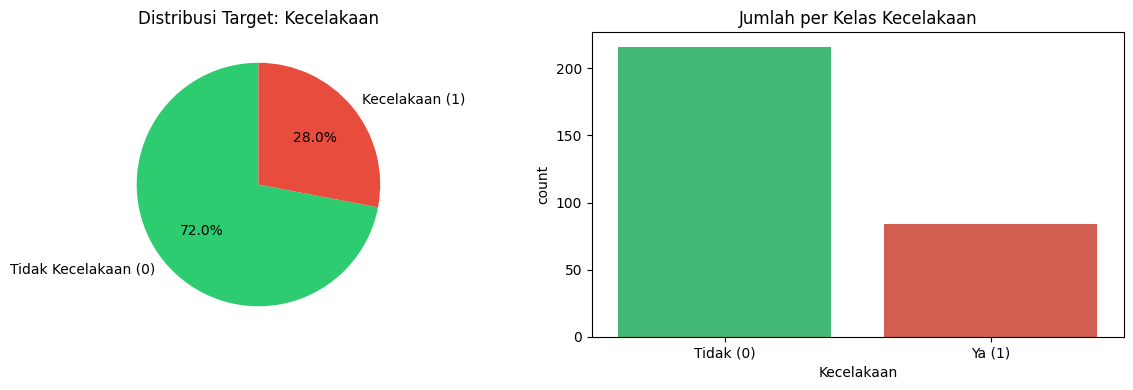

In [3]:
# Visualisasi Distribusi Target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie Chart
df['Kecelakaan'].value_counts().plot.pie(
    autopct='%1.1f%%', labels=['Tidak Kecelakaan (0)', 'Kecelakaan (1)'],
    colors=['#2ecc71', '#e74c3c'], ax=axes[0], startangle=90
)
axes[0].set_title('Distribusi Target: Kecelakaan')
axes[0].set_ylabel('')

# Bar Chart
sns.countplot(x='Kecelakaan', data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Jumlah per Kelas Kecelakaan')
axes[1].set_xticklabels(['Tidak (0)', 'Ya (1)'])
plt.tight_layout()
plt.show()

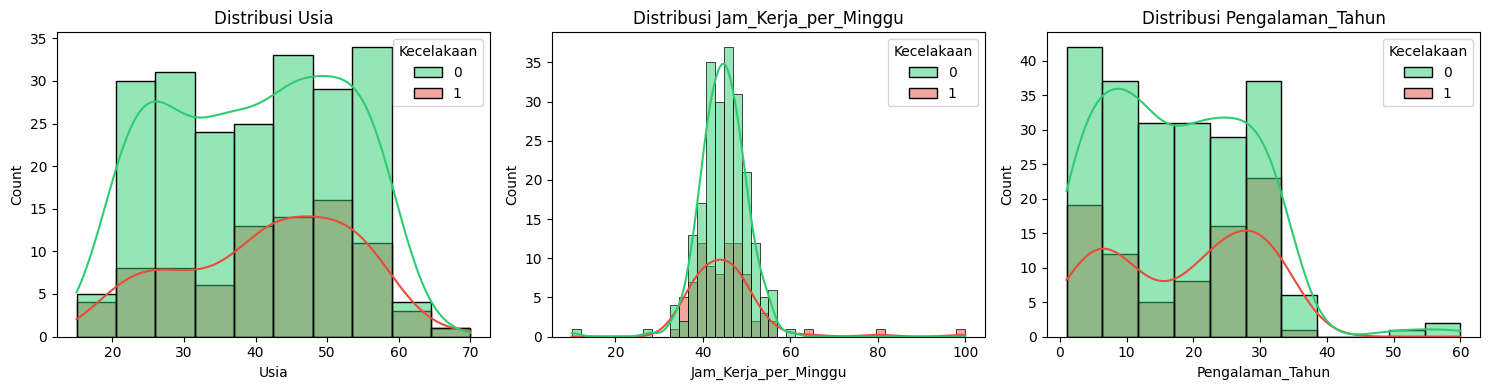

In [4]:
# Distribusi Fitur Numerik
numerical_cols = ['Usia', 'Jam_Kerja_per_Minggu', 'Pengalaman_Tahun']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='Kecelakaan', kde=True, ax=axes[i], palette=['#2ecc71','#e74c3c'])
    axes[i].set_title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

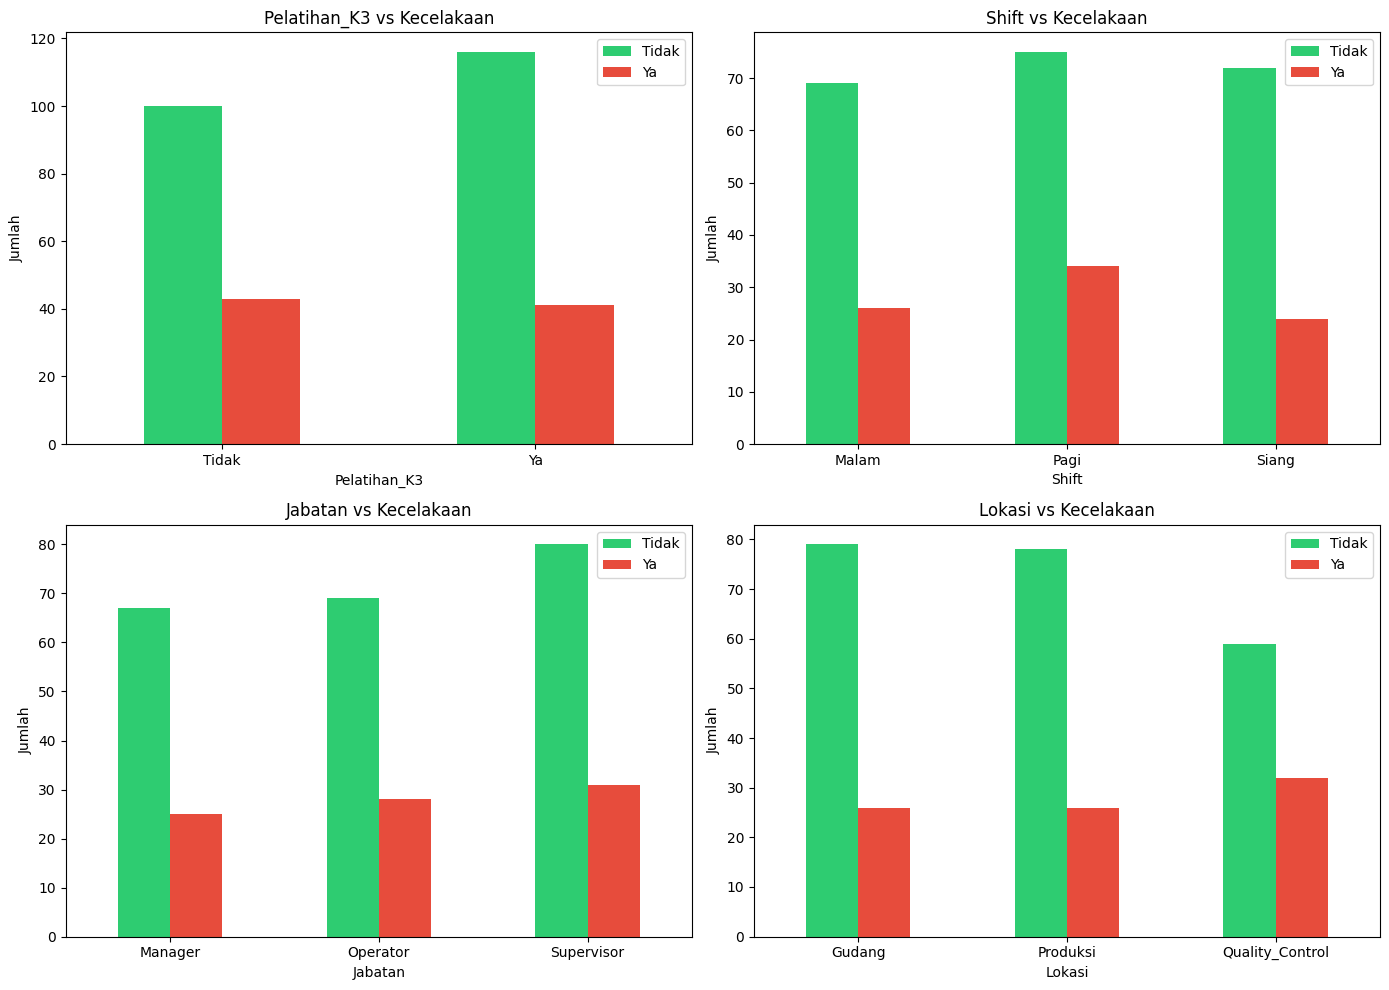

In [5]:
# Distribusi Fitur Kategorik terhadap Target
categorical_cols = ['Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['Kecelakaan'])
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71','#e74c3c'])
    axes[i].set_title(f'{col} vs Kecelakaan')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    axes[i].legend(['Tidak','Ya'])
    axes[i].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

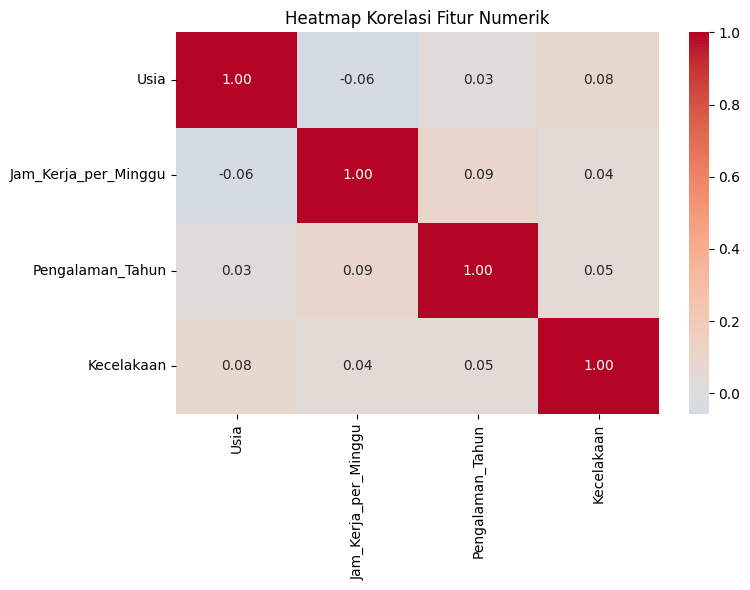

In [6]:
# Heatmap Korelasi (fitur numerik)
plt.figure(figsize=(8, 6))
corr = df[['Usia','Jam_Kerja_per_Minggu','Pengalaman_Tahun','Kecelakaan']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

### 1.2 Data Preprocessing & Feature Engineering

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Buat copy agar data asli tidak berubah
df_model = df.copy()

# Drop kolom ID (tidak relevan untuk model)
if 'ID' in df_model.columns:
    df_model = df_model.drop('ID', axis=1)

# --- Feature Engineering ---
# 1. Encoding variabel kategorik dengan LabelEncoder
categorical_cols = ['Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\n=== Data setelah encoding ===")
display(df_model.head())

Pelatihan_K3: {'Tidak': 0, 'Ya': 1}
Shift: {'Malam': 0, 'Pagi': 1, 'Siang': 2}
Jabatan: {'Manager': 0, 'Operator': 1, 'Supervisor': 2}
Lokasi: {'Gudang': 0, 'Produksi': 1, 'Quality_Control': 2}

=== Data setelah encoding ===


,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan
0,58,47,10,1,1,2,0,0
1,48,44,17,0,2,2,0,0
2,34,40,22,1,1,0,0,0
3,27,37,26,0,0,0,0,0
4,40,42,25,0,1,2,0,0


In [8]:
# Pisahkan fitur (X) dan target (y)
X = df_model.drop('Kecelakaan', axis=1)
y = df_model['Kecelakaan']

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Scaling fitur numerik dengan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Ukuran data training: {X_train_scaled.shape}")
print(f"Ukuran data testing : {X_test_scaled.shape}")
print(f"\nDistribusi target di train:\n{y_train.value_counts()}")
print(f"\nDistribusi target di test:\n{y_test.value_counts()}")

Ukuran data training: (240, 7)
Ukuran data testing : (60, 7)

Distribusi target di train:
Kecelakaan
0    173
1     67
Name: count, dtype: int64

Distribusi target di test:
Kecelakaan
0    43
1    17
Name: count, dtype: int64


### 1.3 Pemodelan Machine Learning
Kita akan membandingkan beberapa algoritma klasifikasi:
1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest
5. Naive Bayes (Gaussian)
6. Support Vector Machine (SVM)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Definisi model
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(kernel='rbf', random_state=42)
}

# Training & Evaluasi semua model
results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

results_df = pd.DataFrame(results)
print("=== Perbandingan Metrik Evaluasi Semua Model ===")
display(results_df)

=== Perbandingan Metrik Evaluasi Semua Model ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7000,0.0000,0.0000,0.0000
1,KNN (k=5),0.6500,0.2500,0.1176,0.1600
2,Decision Tree,0.6167,0.3500,0.4118,0.3784
3,Random Forest,0.6500,0.1667,0.0588,0.0870
4,Naive Bayes,0.6833,0.0000,0.0000,0.0000
5,SVM,0.7167,0.0000,0.0000,0.0000


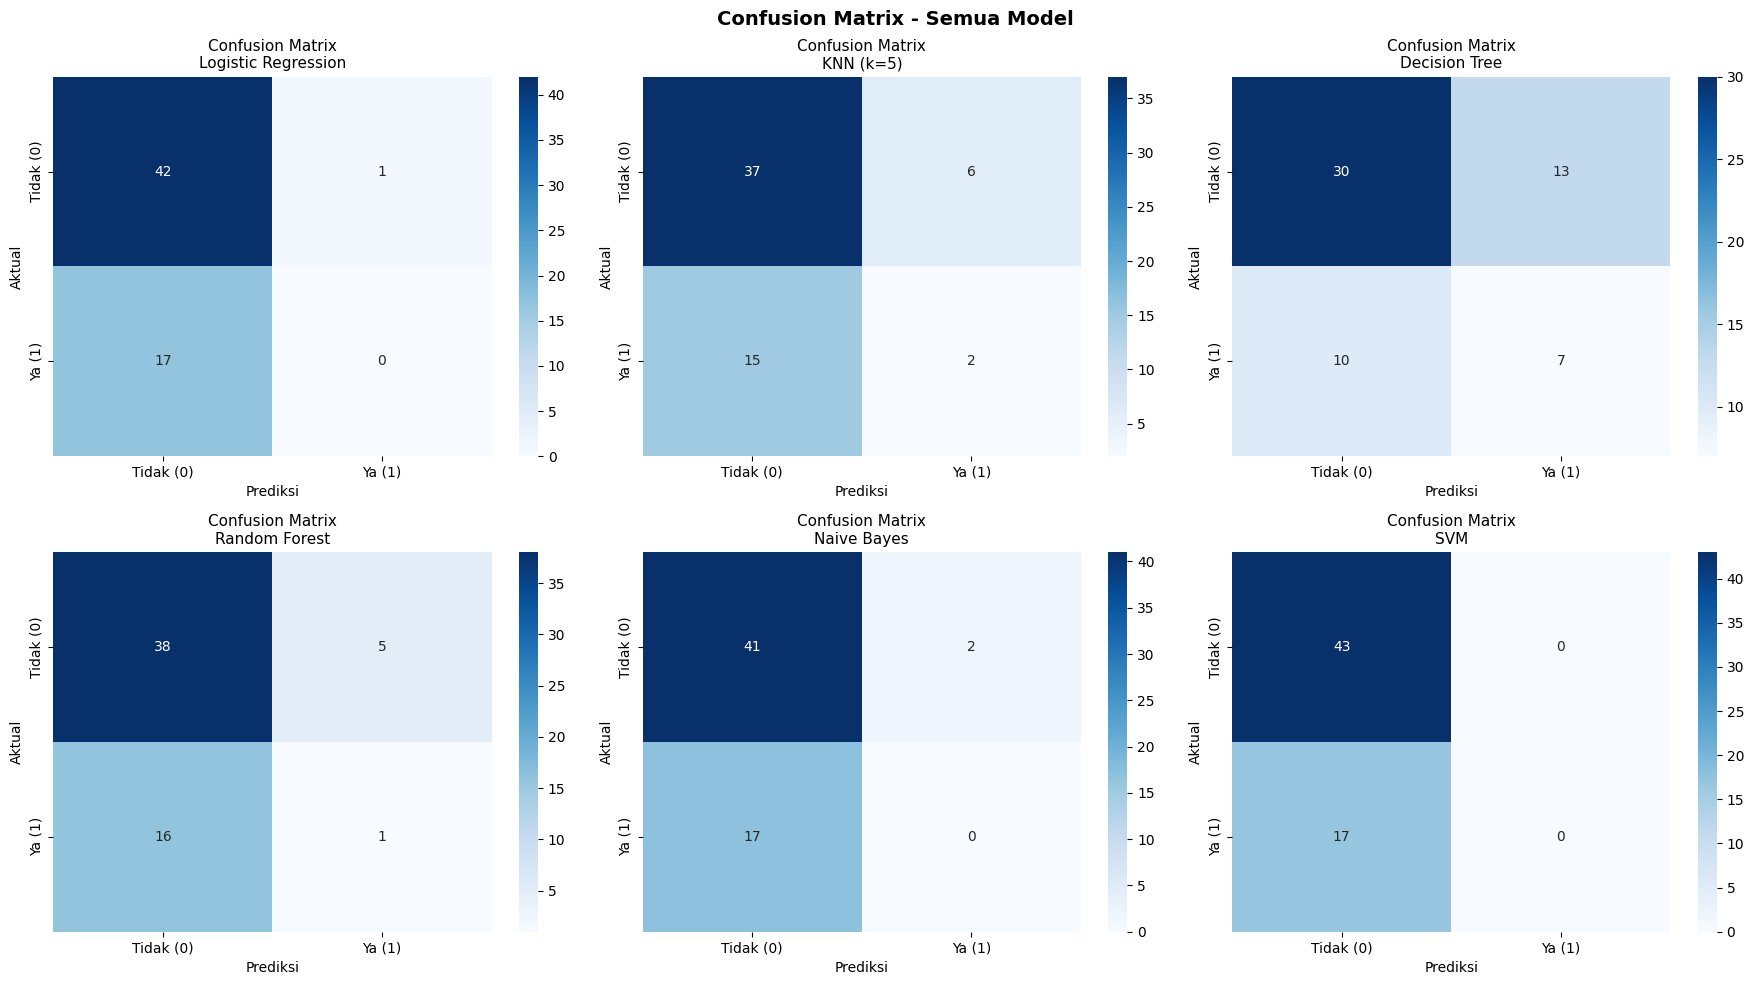

In [10]:
# Visualisasi Confusion Matrix semua model
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Tidak (0)', 'Ya (1)'],
                yticklabels=['Tidak (0)', 'Ya (1)'])
    axes[i].set_title(f'Confusion Matrix\n{name}', fontsize=11)
    axes[i].set_xlabel('Prediksi')
    axes[i].set_ylabel('Aktual')

plt.suptitle('Confusion Matrix - Semua Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Classification Report detail untuk setiap model
for name, y_pred in predictions.items():
    print(f"\n{'='*60}")
    print(f"Classification Report: {name}")
    print('='*60)
    print(classification_report(y_test, y_pred, 
          target_names=['Tidak Kecelakaan (0)', 'Kecelakaan (1)'],
          zero_division=0))


Classification Report: Logistic Regression
                      precision    recall  f1-score   support

Tidak Kecelakaan (0)       0.71      0.98      0.82        43
      Kecelakaan (1)       0.00      0.00      0.00        17

            accuracy                           0.70        60
           macro avg       0.36      0.49      0.41        60
        weighted avg       0.51      0.70      0.59        60


Classification Report: KNN (k=5)
                      precision    recall  f1-score   support

Tidak Kecelakaan (0)       0.71      0.86      0.78        43
      Kecelakaan (1)       0.25      0.12      0.16        17

            accuracy                           0.65        60
           macro avg       0.48      0.49      0.47        60
        weighted avg       0.58      0.65      0.60        60


Classification Report: Decision Tree
                      precision    recall  f1-score   support

Tidak Kecelakaan (0)       0.75      0.70      0.72        43
      Kec

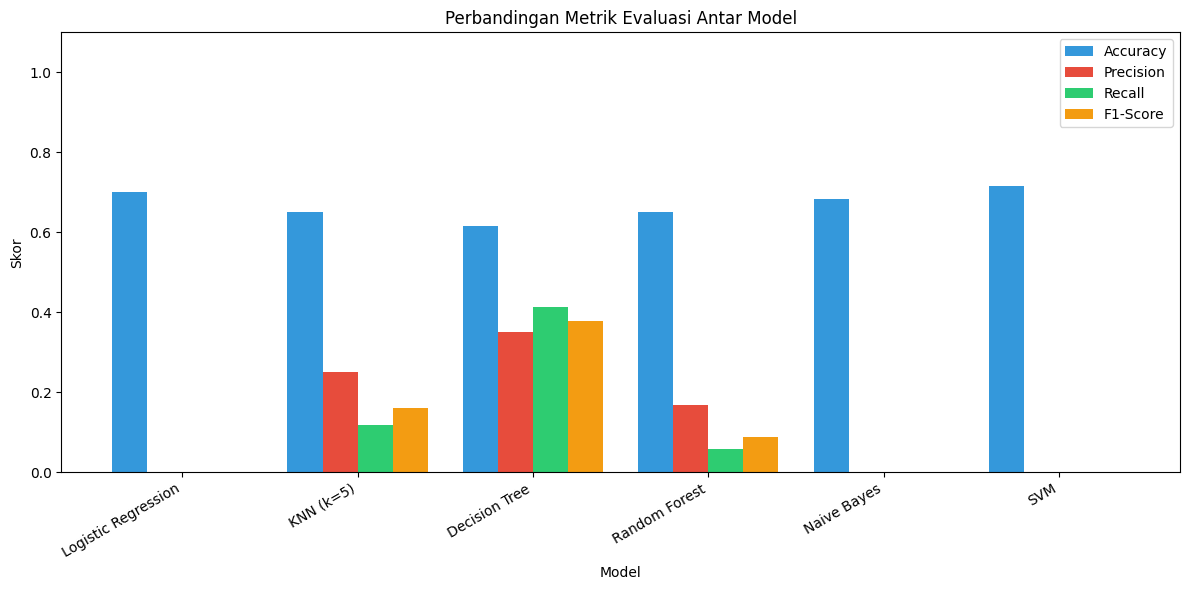

In [12]:
# Visualisasi Perbandingan Metrik antar Model
fig, ax = plt.subplots(figsize=(12, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, metric in enumerate(metrics):
    bars = ax.bar(x + i*width, results_df[metric], width, label=metric, color=colors[i])

ax.set_xlabel('Model')
ax.set_ylabel('Skor')
ax.set_title('Perbandingan Metrik Evaluasi Antar Model')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'], rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

### 1.4 Feature Importance

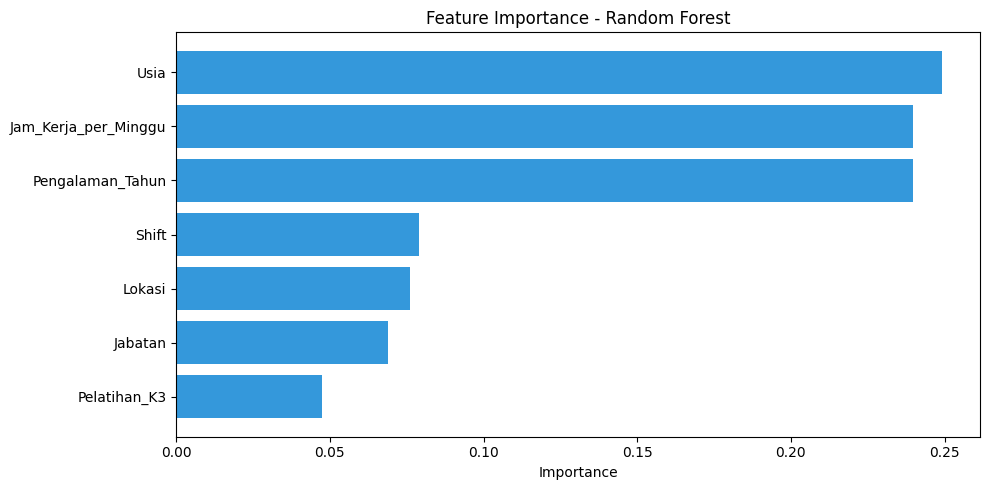


=== Ranking Feature Importance ===


,Fitur,Importance
0,Usia,0.249091
1,Jam_Kerja_per_Minggu,0.239866
2,Pengalaman_Tahun,0.239688
3,Shift,0.079157
4,Lokasi,0.075954
5,Jabatan,0.068936
6,Pelatihan_K3,0.047308


In [13]:
# Feature Importance dari Random Forest
rf_model = models['Random Forest']
feature_names = X.columns
importances = rf_model.feature_importances_

feat_imp_df = pd.DataFrame({
    'Fitur': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(feat_imp_df['Fitur'], feat_imp_df['Importance'], color='#3498db')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

print("\n=== Ranking Feature Importance ===")
display(feat_imp_df.sort_values('Importance', ascending=False).reset_index(drop=True))

### 1.5 Pemilihan Model Terbaik & Kesimpulan Praktik

In [14]:
# Menentukan model terbaik berdasarkan F1-Score
# (F1-Score dipilih karena dataset imbalanced)
best_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_f1 = results_df.loc[best_idx, 'F1-Score']
best_acc = results_df.loc[best_idx, 'Accuracy']

print(f"Model Terbaik: {best_model_name}")
print(f"  - Accuracy : {best_acc}")
print(f"  - F1-Score : {best_f1}")
print(f"\nF1-Score digunakan sebagai metrik utama karena dataset bersifat")
print(f"imbalanced (kelas 0 lebih banyak dari kelas 1), sehingga Accuracy")
print(f"saja tidak cukup untuk mengevaluasi performa model.")

print("\n=== Tabel Lengkap Perbandingan ===")
display(results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True))

Model Terbaik: Decision Tree
  - Accuracy : 0.6167
  - F1-Score : 0.3784

F1-Score digunakan sebagai metrik utama karena dataset bersifat
imbalanced (kelas 0 lebih banyak dari kelas 1), sehingga Accuracy
saja tidak cukup untuk mengevaluasi performa model.

=== Tabel Lengkap Perbandingan ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.6167,0.3500,0.4118,0.3784
1,KNN (k=5),0.6500,0.2500,0.1176,0.1600
2,Random Forest,0.6500,0.1667,0.0588,0.0870
3,Logistic Regression,0.7000,0.0000,0.0000,0.0000
4,Naive Bayes,0.6833,0.0000,0.0000,0.0000
5,SVM,0.7167,0.0000,0.0000,0.0000


---
## Soal 2 - Peran Feature Engineering dalam Pemodelan Machine Learning (20 Point, CLO-4)

**Feature Engineering** adalah proses menggunakan pengetahuan domain (*domain knowledge*) untuk membuat, mengubah, atau menyeleksi fitur-fitur dari data mentah agar model machine learning dapat bekerja lebih optimal. Feature engineering merupakan salah satu tahap **terpenting** dalam pipeline machine learning karena kualitas fitur sangat menentukan kualitas prediksi model.

### Peran Feature Engineering:

1. **Meningkatkan Akurasi Model:**  
   Fitur yang baik dan relevan mempermudah algoritma dalam menemukan pola tersembunyi dalam data, sehingga prediksi menjadi lebih akurat dan reliable.

2. **Mengurangi Kompleksitas & Mencegah Overfitting:**  
   Dengan menyeleksi hanya fitur yang penting atau menggabungkan beberapa fitur menjadi satu, dimensi data dapat dikurangi. Ini mempercepat proses training dan mengurangi risiko model terlalu "menghafal" data training (*overfitting*).

3. **Mengubah Data agar Kompatibel dengan Algoritma:**  
   Banyak algoritma ML hanya menerima input numerik. Fitur kategorik harus ditransformasi terlebih dahulu. Selain itu, beberapa algoritma sensitif terhadap skala data sehingga perlu dilakukan normalisasi/standarisasi.

4. **Merepresentasikan Masalah dengan Lebih Baik:**  
   Kadang fitur mentah tidak langsung menggambarkan pola yang kita cari. Dengan membuat fitur baru yang lebih informatif, model bisa menangkap hubungan yang lebih kompleks.

### Contoh Feature Engineering pada Studi Kasus 1 (Prediksi Kecelakaan Kerja):

| Teknik | Penjelasan | Contoh pada Dataset |
|--------|-----------|---------------------|
| **Label Encoding** | Mengubah variabel kategorik menjadi angka | `Pelatihan_K3`: Ya→1, Tidak→0; `Shift`: Malam→0, Pagi→1, Siang→2 |
| **Standard Scaling** | Menstandarkan fitur numerik agar mean=0 dan std=1 | `Usia` (15-70), `Jam_Kerja_per_Minggu` (10-100), `Pengalaman_Tahun` (1-60) memiliki rentang berbeda-beda. Scaling memastikan semua fitur berkontribusi secara adil |
| **Feature Selection** | Menghapus fitur yang tidak relevan | Kolom `ID` dihapus karena hanya identifier, tidak memiliki nilai prediktif |
| **Stratified Splitting** | Memastikan distribusi kelas target proporsional di data train dan test | Dataset imbalanced (lebih banyak kelas 0), sehingga stratified split penting agar evaluasi representatif |

Pada studi kasus ini, **encoding** dan **scaling** terbukti sangat penting karena:
- Tanpa encoding, algoritma tidak bisa memproses fitur `Pelatihan_K3`, `Shift`, `Jabatan`, dan `Lokasi`.
- Tanpa scaling, algoritma berbasis jarak seperti KNN dan SVM akan bias terhadap fitur dengan nilai besar (misalnya `Jam_Kerja_per_Minggu` yang bisa mencapai 100) dan mengabaikan fitur bernilai kecil.

---
## Soal 3 - Confusion Matrix dan Metrik Evaluasi (20 Point, CLO-4)

### Apa itu Confusion Matrix?

**Confusion Matrix** (Matriks Kebingungan) adalah sebuah tabel yang digunakan untuk **mengevaluasi kinerja model klasifikasi** dengan cara membandingkan nilai aktual (sebenarnya) dengan nilai yang diprediksi oleh model. 

Pada Studi Kasus 1 (klasifikasi biner: Kecelakaan atau Tidak), confusion matrix berukuran 2×2 yang terdiri dari:

|  | **Prediksi: Tidak (0)** | **Prediksi: Ya (1)** |
|--|------------------------|---------------------|
| **Aktual: Tidak (0)** | **True Negative (TN)** | **False Positive (FP)** |
| **Aktual: Ya (1)** | **False Negative (FN)** | **True Positive (TP)** |

Penjelasan masing-masing komponen pada studi kasus ini:

1. **True Positive (TP):** Karyawan yang **diprediksi mengalami kecelakaan** dan **memang benar** mengalami kecelakaan. ✅
2. **True Negative (TN):** Karyawan yang **diprediksi tidak mengalami kecelakaan** dan **memang benar** tidak mengalami kecelakaan. ✅
3. **False Positive (FP) - Type I Error:** Karyawan yang **diprediksi mengalami kecelakaan**, padahal **sebenarnya tidak**. (Alarm palsu / *false alarm*) ❌
4. **False Negative (FN) - Type II Error:** Karyawan yang **diprediksi tidak mengalami kecelakaan**, padahal **sebenarnya mengalami** kecelakaan. (Kasus terlewat / *missed case*) ❌

### Metrik Evaluasi yang Diturunkan dari Confusion Matrix:

| Metrik | Formula | Penjelasan pada Studi Kasus |
|--------|---------|----------------------------|
| **Accuracy** | (TP + TN) / (TP + TN + FP + FN) | Persentase prediksi yang benar secara keseluruhan. Namun, pada studi kasus ini dataset **imbalanced** (~70% kelas 0), sehingga accuracy bisa menyesatkan. Model yang selalu prediksi "Tidak" saja sudah mendapat accuracy ~70%. |
| **Precision** | TP / (TP + FP) | Dari semua karyawan yang **diprediksi akan kecelakaan**, berapa persen yang **benar-benar kecelakaan**? Penting jika biaya False Positive tinggi (misal: biaya intervensi pencegahan yang sia-sia). |
| **Recall (Sensitivity)** | TP / (TP + FN) | Dari semua karyawan yang **sebenarnya mengalami kecelakaan**, berapa persen yang **berhasil terdeteksi** oleh model? **Sangat krusial pada studi kasus ini** karena False Negative berarti karyawan berisiko tinggi **lolos dari pengawasan** dan berpotensi celaka. |
| **F1-Score** | 2 × (Precision × Recall) / (Precision + Recall) | Rata-rata harmonis dari Precision dan Recall. Berguna ketika kita perlu **keseimbangan** antara keduanya, terutama saat dataset imbalanced seperti pada studi kasus ini. |

### Mengapa Recall Sangat Penting pada Studi Kasus Ini?

Pada konteks prediksi kecelakaan kerja, **False Negative jauh lebih berbahaya daripada False Positive**:
- **False Positive** (prediksi kecelakaan padahal tidak): Hanya menyebabkan pemberian pelatihan/pengawasan ekstra yang sebenarnya tidak perlu → kerugian biaya.
- **False Negative** (prediksi aman padahal berisiko): Karyawan yang seharusnya mendapat perhatian khusus **tidak terdeteksi** → dapat mengakibatkan **cedera atau kematian**.

Oleh karena itu, pada studi kasus prediksi kecelakaan kerja ini, **Recall** dan **F1-Score** menjadi metrik evaluasi yang lebih tepat dibandingkan Accuracy semata.